# 02 — Practical DNA & RNA Sequence Analysis with Python

## A project-oriented lesson in computational sequence analysis

This notebook moves from Python fundamentals toward a realistic sequence-analysis workflow.

We will build a transparent pipeline that can:

- normalize and validate DNA sequences,
- perform quality control,
- calculate nucleotide composition and GC/AT content,
- analyze sequence statistics,
- search for motifs,
- generate reverse complements,
- inspect reading frames,
- translate DNA,
- detect simple ORFs,
- summarize codon usage,
- compare reference and sample sequences,
- calculate positional identity,
- visualize sequence-level measurements,
- analyze multiple samples,
- and produce an integrated report.

> **Scope note:** These implementations are intentionally educational. They are not replacements for production-grade alignment, variant calling, genome annotation, or clinical interpretation pipelines.

## Learning objectives

By the end of this notebook, you should be able to:

1. Treat a biological sequence as structured computational data.
2. Design reusable functions for sequence analysis.
3. Implement DNA quality-control checks.
4. Compute nucleotide composition and GC content.
5. Search for exact motifs and report their positions.
6. Work with reverse complements.
7. Understand reading frames and codons.
8. Translate DNA using the standard genetic code.
9. Detect simple ORFs on both strands.
10. Compare reference and sample sequences.
11. Distinguish positional identity from true sequence alignment.
12. Analyze a collection of sequences.
13. Visualize sequence-level measurements.
14. Build a compact end-to-end bioinformatics pipeline.
15. Understand where specialized tools such as Biopython become useful.

## Project scenario

Imagine that a research group has generated a small collection of DNA sequences from several samples.

We want to answer practical questions:

- Are the sequences valid?
- Are they long enough?
- Do they contain ambiguous bases?
- What is their nucleotide composition?
- How GC-rich are they?
- Does a sequence contain a motif of interest?
- What coding regions could exist under a simple ORF model?
- What amino-acid sequence would a coding region produce?
- How different is a sample from a reference?
- Can the analysis be repeated automatically across many samples?

### Workflow

```text
Raw sequence
    ↓
Normalization
    ↓
Quality control
    ↓
Composition & statistics
    ↓
Motif analysis
    ↓
Reverse complement
    ↓
Reading frames
    ↓
Translation
    ↓
ORF detection
    ↓
Codon analysis
    ↓
Reference/sample comparison
    ↓
Visualization
    ↓
Batch analysis
    ↓
Integrated report
```

## 1. Imports

We use NumPy for numerical statistics, Matplotlib for visualization, and Python's standard library for sequence operations.

Biopython is intentionally not used yet. The purpose is to understand the underlying operations before introducing specialized bioinformatics abstractions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

## 2. A small reproducible synthetic dataset

The dataset is self-contained so the notebook can run without internet access.

The sequences are synthetic and are not intended to represent real patient or genomic data.

In [2]:
REFERENCE_SEQUENCE = "ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG"

SAMPLES = [
    {"sample_id": "S01", "group": "control",
     "sequence": "ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG"},
    {"sample_id": "S02", "group": "control",
     "sequence": "ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAC"},
    {"sample_id": "S03", "group": "treated",
     "sequence": "ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG"},
    {"sample_id": "S04", "group": "treated",
     "sequence": "ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATGC"},
    {"sample_id": "S05", "group": "treated",
     "sequence": "ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATNN"},
]

INVALID_SEQUENCE = "ATGCCXTTGGA"

print("Reference length:", len(REFERENCE_SEQUENCE))
print("Number of samples:", len(SAMPLES))

Reference length: 39
Number of samples: 5


## 3. Sequence normalization

Biological sequences may contain lowercase letters, spaces, line breaks, or FASTA-style headers.

Normalization makes equivalent inputs behave consistently.

In [3]:
def normalize_sequence(sequence: str) -> str:
    # Normalize a DNA/RNA sequence for downstream analysis.
    sequence = str(sequence).strip()

    # Remove a FASTA-style header when present.
    if sequence.startswith(">"):
        sequence = sequence.split("\n", 1)[1] if "\n" in sequence else ""

    # Remove whitespace and standardize to uppercase.
    return "".join(sequence.split()).upper()


examples = ["atggcc", " ATG GCC ", ">sample_1\nATG GCC ATT"]

for example in examples:
    print(normalize_sequence(example))

ATGGCC
ATGGCC
ATGGCCATT


## 4. DNA quality control

A basic QC system should distinguish:

- canonical DNA bases: `A`, `T`, `C`, `G`,
- ambiguous bases such as `N`,
- invalid characters,
- empty sequences,
- unusually short sequences.

Instead of returning only `True` or `False`, the function returns useful diagnostic information.

In [4]:
DNA_BASES = set("ATCG")
DNA_BASES_WITH_N = DNA_BASES | {"N"}


def quality_control(
    sequence: str,
    min_length: int = 10,
    allow_ambiguous: bool = True
) -> Dict:
    seq = normalize_sequence(sequence)

    if not seq:
        return {
            "valid": False,
            "length": 0,
            "invalid_bases": [],
            "ambiguous_count": 0,
            "ambiguous_fraction": 0.0,
            "status": "empty sequence"
        }

    allowed = DNA_BASES_WITH_N if allow_ambiguous else DNA_BASES
    invalid_bases = sorted(set(seq) - allowed)
    ambiguous_count = seq.count("N")
    ambiguous_fraction = ambiguous_count / len(seq)

    checks_passed = len(seq) >= min_length and len(invalid_bases) == 0

    if not allow_ambiguous and ambiguous_count > 0:
        checks_passed = False

    if len(seq) < min_length:
        status = "too short"
    elif invalid_bases:
        status = "contains invalid bases"
    elif not allow_ambiguous and ambiguous_count:
        status = "contains ambiguous bases"
    else:
        status = "pass"

    return {
        "valid": checks_passed,
        "length": len(seq),
        "invalid_bases": invalid_bases,
        "ambiguous_count": ambiguous_count,
        "ambiguous_fraction": ambiguous_fraction,
        "status": status
    }


for label, sequence in [
    ("reference", REFERENCE_SEQUENCE),
    ("ambiguous", SAMPLES[-1]["sequence"]),
    ("invalid", INVALID_SEQUENCE),
]:
    print(label, "->", quality_control(sequence))

reference -> {'valid': True, 'length': 39, 'invalid_bases': [], 'ambiguous_count': 0, 'ambiguous_fraction': 0.0, 'status': 'pass'}
ambiguous -> {'valid': True, 'length': 39, 'invalid_bases': [], 'ambiguous_count': 2, 'ambiguous_fraction': 0.05128205128205128, 'status': 'pass'}
invalid -> {'valid': False, 'length': 11, 'invalid_bases': ['X'], 'ambiguous_count': 0, 'ambiguous_fraction': 0.0, 'status': 'contains invalid bases'}


### Interpreting QC

A sequence can be syntactically valid but still unsuitable for a particular analysis.

QC thresholds depend on the biological task. A minimum length that is appropriate for one experiment may be inappropriate for another.

## 5. Nucleotide composition

For a sequence of length `L`, the frequency of nucleotide `X` is:

$$
f_X = \frac{\text{count}(X)}{L}
$$

Composition is one of the simplest sequence-level summaries and becomes particularly useful when comparing many samples.

In [5]:
def nucleotide_counts(sequence: str) -> Dict[str, int]:
    seq = normalize_sequence(sequence)
    counts = Counter(seq)
    return {base: counts.get(base, 0) for base in "ATCG"}


def nucleotide_frequencies(sequence: str) -> Dict[str, float]:
    seq = normalize_sequence(sequence)

    if not seq:
        return {base: 0.0 for base in "ATCG"}

    counts = nucleotide_counts(seq)
    return {base: counts[base] / len(seq) for base in "ATCG"}


print("Counts:", nucleotide_counts(REFERENCE_SEQUENCE))
print("Frequencies:", nucleotide_frequencies(REFERENCE_SEQUENCE))

Counts: {'A': 9, 'T': 8, 'C': 8, 'G': 14}
Frequencies: {'A': 0.23076923076923078, 'T': 0.20512820512820512, 'C': 0.20512820512820512, 'G': 0.358974358974359}


## 6. GC, AT, and ambiguous-base content

GC content:

$$
GC\% = \frac{G+C}{L} \times 100
$$

AT content:

$$
AT\% = \frac{A+T}{L} \times 100
$$

We also calculate the percentage of ambiguous `N` bases.

In [29]:
def gc_content(sequence: str) -> float:
    seq = normalize_sequence(sequence)
    return 0.0 if not seq else (seq.count("G") + seq.count("C")) / len(seq) * 100


def at_content(sequence: str) -> float:
    seq = normalize_sequence(sequence)
    return 0.0 if not seq else (seq.count("A") + seq.count("T")) / len(seq) * 100


def ambiguous_percentage(sequence: str) -> float:
    seq = normalize_sequence(sequence)
    return 0.0 if not seq else seq.count("N") / len(seq) * 100


print(f"GC content: {gc_content(REFERENCE_SEQUENCE):.2f}%")
print(f"AT content: {at_content(REFERENCE_SEQUENCE):.2f}%")
print(f"N content:  {ambiguous_percentage(SAMPLES[-1]['sequence']):.2f}%")

GC content: 56.41%
AT content: 43.59%
N content:  5.13%


## 7. Sequence-length statistics

For multiple sequences, useful descriptive statistics include minimum, maximum, mean, median, and standard deviation.

In [30]:
lengths = np.array([
    len(normalize_sequence(sample["sequence"]))
    for sample in SAMPLES
])

length_summary = {
    "count": len(lengths),
    "min": int(np.min(lengths)),
    "max": int(np.max(lengths)),
    "mean": float(np.mean(lengths)),
    "median": float(np.median(lengths)),
    "std": float(np.std(lengths))
}

length_summary

{'count': 5, 'min': 39, 'max': 39, 'mean': 39.0, 'median': 39.0, 'std': 0.0}

## 8. Exact motif analysis

We search for exact sequence motifs and report:

- occurrence count,
- zero-based positions,
- frequency relative to sequence length.

This is an exact string-search method. Real biological motifs may be degenerate, strand-dependent, probabilistic, or separated by variable spacing.

In [31]:
def find_motif(sequence: str, motif: str) -> Dict:
    seq = normalize_sequence(sequence)
    motif = normalize_sequence(motif)

    if not motif:
        return {"motif": motif, "count": 0, "positions": [], "frequency": 0.0}

    # Check every possible starting position, so overlapping motifs are retained.
    positions = [
        i
        for i in range(len(seq) - len(motif) + 1)
        if seq[i:i + len(motif)] == motif
    ]

    return {
        "motif": motif,
        "count": len(positions),
        "positions": positions,
        "frequency": len(positions) / len(seq) if seq else 0.0
    }


print(find_motif(REFERENCE_SEQUENCE, "ATG"))
print(find_motif("AAAAA", "AAA"))

{'motif': 'ATG', 'count': 2, 'positions': [0, 12], 'frequency': 0.05128205128205128}
{'motif': 'AAA', 'count': 3, 'positions': [0, 1, 2], 'frequency': 0.6}


## 9. Reverse complement

DNA is double-stranded. The reverse complement is obtained by complementing `A ↔ T` and `C ↔ G`, then reversing the sequence.

This operation is essential whenever strand orientation matters.

In [32]:
COMPLEMENT = str.maketrans({
    "A": "T",
    "T": "A",
    "C": "G",
    "G": "C",
    "N": "N"
})


def reverse_complement(sequence: str) -> str:
    seq = normalize_sequence(sequence)
    return seq.translate(COMPLEMENT)[::-1]


print("Sequence:          ATGC")
print("Reverse complement:", reverse_complement("ATGC"))

Sequence:          ATGC
Reverse complement: GCAT


## 10. Reading frames and codons

DNA is interpreted in groups of three nucleotides.

One strand has three reading frames. Considering the reverse complement gives three additional frames, for six possible reading frames in total.

In [33]:
def get_codons(sequence: str, frame: int = 0) -> List[str]:
    seq = normalize_sequence(sequence)

    if frame not in (0, 1, 2):
        raise ValueError("frame must be 0, 1, or 2")

    return [
        seq[i:i + 3]
        for i in range(frame, len(seq) - 2, 3)
    ]


for frame in range(3):
    print(f"Frame +{frame + 1}:", get_codons(REFERENCE_SEQUENCE, frame))

Frame +1: ['ATG', 'GCC', 'ATT', 'GTA', 'ATG', 'GGC', 'CGC', 'TGA', 'AAG', 'GGT', 'GCC', 'CGA', 'TAG']
Frame +2: ['TGG', 'CCA', 'TTG', 'TAA', 'TGG', 'GCC', 'GCT', 'GAA', 'AGG', 'GTG', 'CCC', 'GAT']
Frame +3: ['GGC', 'CAT', 'TGT', 'AAT', 'GGG', 'CCG', 'CTG', 'AAA', 'GGG', 'TGC', 'CCG', 'ATA']


## 11. The standard genetic code

There are 64 possible DNA codons:

- 61 sense codons,
- 3 standard stop codons: `TAA`, `TAG`, `TGA`.

The genetic code is redundant: multiple codons can encode the same amino acid.

In [34]:
CODON_TABLE = {
    "TTT": "F", "TTC": "F", "TTA": "L", "TTG": "L",
    "CTT": "L", "CTC": "L", "CTA": "L", "CTG": "L",
    "ATT": "I", "ATC": "I", "ATA": "I", "ATG": "M",
    "GTT": "V", "GTC": "V", "GTA": "V", "GTG": "V",
    "TCT": "S", "TCC": "S", "TCA": "S", "TCG": "S",
    "AGT": "S", "AGC": "S",
    "CCT": "P", "CCC": "P", "CCA": "P", "CCG": "P",
    "ACT": "T", "ACC": "T", "ACA": "T", "ACG": "T",
    "GCT": "A", "GCC": "A", "GCA": "A", "GCG": "A",
    "TAT": "Y", "TAC": "Y", "TAA": "*", "TAG": "*",
    "CAT": "H", "CAC": "H", "CAA": "Q", "CAG": "Q",
    "AAT": "N", "AAC": "N", "AAA": "K", "AAG": "K",
    "GAT": "D", "GAC": "D", "GAA": "E", "GAG": "E",
    "TGT": "C", "TGC": "C", "TGA": "*", "TGG": "W",
    "CGT": "R", "CGC": "R", "CGA": "R", "CGG": "R",
    "AGA": "R", "AGG": "R",
    "GGT": "G", "GGC": "G", "GGA": "G", "GGG": "G"
}

STOP_CODONS = {"TAA", "TAG", "TGA"}
START_CODON = "ATG"

## 12. DNA translation

Our educational translator:

- ignores an incomplete final codon,
- represents unknown or ambiguous codons as `X`,
- represents stop codons as `*`,
- optionally stops at the first stop codon.

In [35]:
def translate_dna(
    sequence: str,
    frame: int = 0,
    stop_at_stop: bool = False
) -> str:
    amino_acids = []

    for codon in get_codons(sequence, frame):
        amino_acid = CODON_TABLE.get(codon, "X")

        if stop_at_stop and amino_acid == "*":
            break

        amino_acids.append(amino_acid)

    return "".join(amino_acids)


for frame in range(3):
    print(f"Frame +{frame + 1}: {translate_dna(REFERENCE_SEQUENCE, frame)}")

Frame +1: MAIVMGR*KGAR*
Frame +2: WPL*WAAERVPD
Frame +3: GHCNGPLKGCPI


### Important biological limitation

Translation alone does not prove that a sequence is a real gene.

A computationally translatable region may be biologically meaningless. Gene identification normally requires additional evidence such as annotation, genomic context, conservation, transcript evidence, or experimental support.

## 13. Simple ORF detection

For this notebook, an ORF is defined by a simplified rule:

1. find `ATG`,
2. continue in the same reading frame,
3. stop at the first in-frame stop codon.

We search all three frames on both the forward sequence and reverse complement.

This is an educational ORF finder, not a complete gene-prediction algorithm.

In [36]:
@dataclass
class ORF:
    strand: str
    frame: int
    start: int
    end: int
    nucleotide_sequence: str
    protein_sequence: str


def find_orfs_one_strand(sequence: str, strand: str = "+") -> List[ORF]:
    seq = normalize_sequence(sequence)
    results = []

    for frame in range(3):
        i = frame

        while i <= len(seq) - 3:
            if seq[i:i + 3] == START_CODON:
                j = i + 3

                while j <= len(seq) - 3:
                    if seq[j:j + 3] in STOP_CODONS:
                        nucleotide = seq[i:j + 3]
                        protein = translate_dna(
                            nucleotide,
                            frame=0,
                            stop_at_stop=True
                        )

                        results.append(
                            ORF(
                                strand=strand,
                                frame=frame + 1,
                                start=i,
                                end=j + 3,
                                nucleotide_sequence=nucleotide,
                                protein_sequence=protein
                            )
                        )
                        break

                    j += 3

            i += 3

    return results


def find_six_frame_orfs(sequence: str) -> List[ORF]:
    seq = normalize_sequence(sequence)
    return (
        find_orfs_one_strand(seq, strand="+")
        + find_orfs_one_strand(reverse_complement(seq), strand="-")
    )


orfs = find_six_frame_orfs(REFERENCE_SEQUENCE)

for orf in orfs:
    print(orf)

ORF(strand='+', frame=1, start=0, end=24, nucleotide_sequence='ATGGCCATTGTAATGGGCCGCTGA', protein_sequence='MAIVMGR')
ORF(strand='+', frame=1, start=12, end=24, nucleotide_sequence='ATGGGCCGCTGA', protein_sequence='MGR')


## 14. Codon usage

Codon usage describes how frequently codons occur in a coding sequence.

For a small sequence this is descriptive only. Meaningful codon-usage analysis usually requires larger datasets and biological context.

In [37]:
def codon_usage(sequence: str, frame: int = 0) -> Dict[str, int]:
    return dict(sorted(Counter(get_codons(sequence, frame)).items()))


for codon, count in codon_usage(REFERENCE_SEQUENCE).items():
    print(f"{codon}: {count}")

AAG: 1
ATG: 2
ATT: 1
CGA: 1
CGC: 1
GCC: 2
GGC: 1
GGT: 1
GTA: 1
TAG: 1
TGA: 1


## 15. Reference versus sample comparison

For equal-length sequences, a first comparison is a position-by-position scan.

Every difference is reported as a single-base difference.

> This is deliberately limited to equal-length sequences. Insertions and deletions require alignment or another coordinate-aware method.

In [38]:
def compare_equal_length_sequences(
    reference: str,
    sample: str
) -> List[Dict]:
    ref = normalize_sequence(reference)
    alt = normalize_sequence(sample)

    if len(ref) != len(alt):
        raise ValueError(
            "Sequences must have equal length for positional comparison. "
            "Use an alignment method for indels."
        )

    differences = []

    for position, (ref_base, alt_base) in enumerate(zip(ref, alt), start=1):
        if ref_base != alt_base:
            differences.append({
                "position": position,
                "reference": ref_base,
                "sample": alt_base,
                "type": "SNV"
            })

    return differences


for sample in SAMPLES:
    if len(sample["sequence"]) == len(REFERENCE_SEQUENCE):
        print(
            sample["sample_id"],
            compare_equal_length_sequences(
                REFERENCE_SEQUENCE,
                sample["sequence"]
            )
        )

S01 []
S02 [{'position': 39, 'reference': 'G', 'sample': 'C', 'type': 'SNV'}]
S03 []
S04 [{'position': 38, 'reference': 'A', 'sample': 'G', 'type': 'SNV'}, {'position': 39, 'reference': 'G', 'sample': 'C', 'type': 'SNV'}]
S05 [{'position': 38, 'reference': 'A', 'sample': 'N', 'type': 'SNV'}, {'position': 39, 'reference': 'G', 'sample': 'N', 'type': 'SNV'}]


## 16. Positional identity

For two equal-length sequences:

$$
Identity = \frac{\text{matching positions}}{\text{sequence length}}
$$

This is useful as a basic similarity measure, but it is **not sequence alignment**.

In [39]:
def positional_identity(reference: str, sample: str) -> float:
    ref = normalize_sequence(reference)
    alt = normalize_sequence(sample)

    if len(ref) != len(alt):
        raise ValueError("Sequences must have equal length.")

    if not ref:
        return 0.0

    matches = sum(
        ref_base == alt_base
        for ref_base, alt_base in zip(ref, alt)
    )

    return matches / len(ref)


for sample in SAMPLES:
    if len(sample["sequence"]) == len(REFERENCE_SEQUENCE):
        identity = positional_identity(
            REFERENCE_SEQUENCE,
            sample["sequence"]
        )
        print(sample["sample_id"], f"{identity:.2%}")

S01 100.00%
S02 97.44%
S03 100.00%
S04 94.87%
S05 94.87%


## 17. Reusable per-sequence analysis

We now combine the low-level functions into a single structured analysis.

This is the transition from individual programming exercises toward a small analysis framework.

In [40]:
def analyze_sequence(sequence: str, min_length: int = 10) -> Dict:
    seq = normalize_sequence(sequence)
    qc = quality_control(seq, min_length=min_length)

    return {
        "sequence": seq,
        "length": len(seq),
        "gc_percent": gc_content(seq),
        "at_percent": at_content(seq),
        "n_percent": ambiguous_percentage(seq),
        "qc": qc,
        "nucleotide_counts": nucleotide_counts(seq),
        "atg_motif": find_motif(seq, "ATG"),
        "orfs": find_six_frame_orfs(seq),
    }


reference_report = analyze_sequence(REFERENCE_SEQUENCE)

print("Length:", reference_report["length"])
print("GC%:", f"{reference_report['gc_percent']:.2f}")
print("QC:", reference_report["qc"]["status"])
print("ATG occurrences:", reference_report["atg_motif"]["count"])
print("ORFs:", len(reference_report["orfs"]))

Length: 39
GC%: 56.41
QC: pass
ATG occurrences: 2
ORFs: 2


## 18. Batch analysis

Real bioinformatics datasets contain many sequences.

We apply the same analysis to every sample and keep the results in a list of dictionaries. This structure can later become a pandas DataFrame.

In [41]:
def analyze_dataset(
    samples: List[Dict],
    min_length: int = 10
) -> List[Dict]:
    records = []

    for sample in samples:
        analysis = analyze_sequence(
            sample["sequence"],
            min_length=min_length
        )

        records.append({
            "sample_id": sample["sample_id"],
            "group": sample["group"],
            "length": analysis["length"],
            "gc_percent": analysis["gc_percent"],
            "at_percent": analysis["at_percent"],
            "n_percent": analysis["n_percent"],
            "qc_status": analysis["qc"]["status"],
            "qc_valid": analysis["qc"]["valid"],
            "atg_count": analysis["atg_motif"]["count"],
            "orf_count": len(analysis["orfs"]),
        })

    return records


dataset_report = analyze_dataset(SAMPLES)

for record in dataset_report:
    print(record)

{'sample_id': 'S01', 'group': 'control', 'length': 39, 'gc_percent': 56.41025641025641, 'at_percent': 43.58974358974359, 'n_percent': 0.0, 'qc_status': 'pass', 'qc_valid': True, 'atg_count': 2, 'orf_count': 2}
{'sample_id': 'S02', 'group': 'control', 'length': 39, 'gc_percent': 56.41025641025641, 'at_percent': 43.58974358974359, 'n_percent': 0.0, 'qc_status': 'pass', 'qc_valid': True, 'atg_count': 2, 'orf_count': 2}
{'sample_id': 'S03', 'group': 'treated', 'length': 39, 'gc_percent': 56.41025641025641, 'at_percent': 43.58974358974359, 'n_percent': 0.0, 'qc_status': 'pass', 'qc_valid': True, 'atg_count': 2, 'orf_count': 2}
{'sample_id': 'S04', 'group': 'treated', 'length': 39, 'gc_percent': 58.97435897435898, 'at_percent': 41.02564102564102, 'n_percent': 0.0, 'qc_status': 'pass', 'qc_valid': True, 'atg_count': 3, 'orf_count': 2}
{'sample_id': 'S05', 'group': 'treated', 'length': 39, 'gc_percent': 53.84615384615385, 'at_percent': 41.02564102564102, 'n_percent': 5.128205128205128, 'qc_sta

# 19. Visualization

We will create separate plots for:

- nucleotide composition,
- GC content,
- sequence length,
- motif positions,
- codon usage,
- mutation positions.

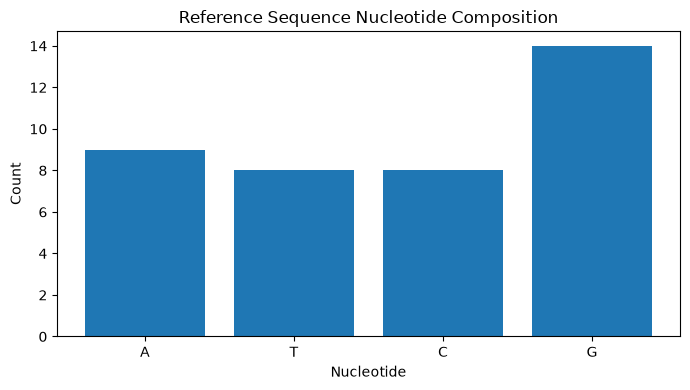

In [42]:
counts = nucleotide_counts(REFERENCE_SEQUENCE)

plt.figure(figsize=(7, 4))
plt.bar(list(counts.keys()), list(counts.values()))
plt.title("Reference Sequence Nucleotide Composition")
plt.xlabel("Nucleotide")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

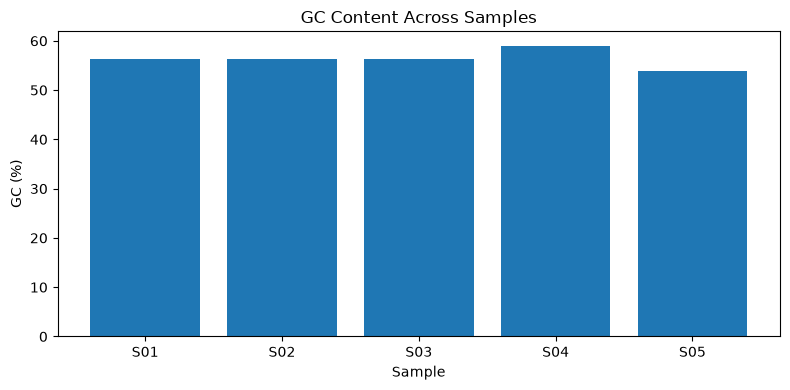

In [43]:
sample_ids = [record["sample_id"] for record in dataset_report]
gc_values = [record["gc_percent"] for record in dataset_report]

plt.figure(figsize=(8, 4))
plt.bar(sample_ids, gc_values)
plt.title("GC Content Across Samples")
plt.xlabel("Sample")
plt.ylabel("GC (%)")
plt.tight_layout()
plt.show()

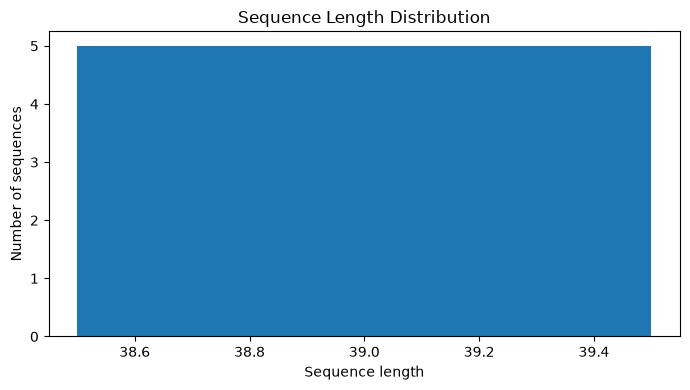

In [44]:
dataset_lengths = [record["length"] for record in dataset_report]

plt.figure(figsize=(7, 4))
plt.hist(dataset_lengths, bins=min(10, max(1, len(set(dataset_lengths)))))
plt.title("Sequence Length Distribution")
plt.xlabel("Sequence length")
plt.ylabel("Number of sequences")
plt.tight_layout()
plt.show()

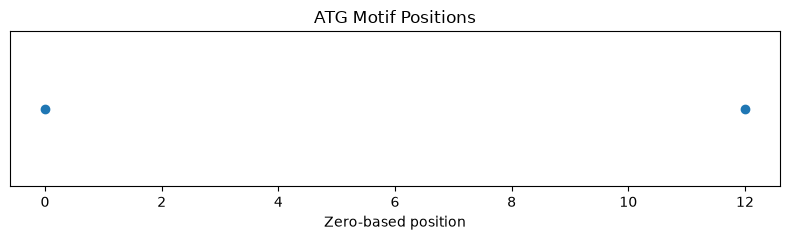

In [45]:
motif_positions = find_motif(REFERENCE_SEQUENCE, "ATG")["positions"]

plt.figure(figsize=(8, 2.5))
plt.scatter(motif_positions, [1] * len(motif_positions))
plt.yticks([])
plt.xlabel("Zero-based position")
plt.title("ATG Motif Positions")
plt.tight_layout()
plt.show()

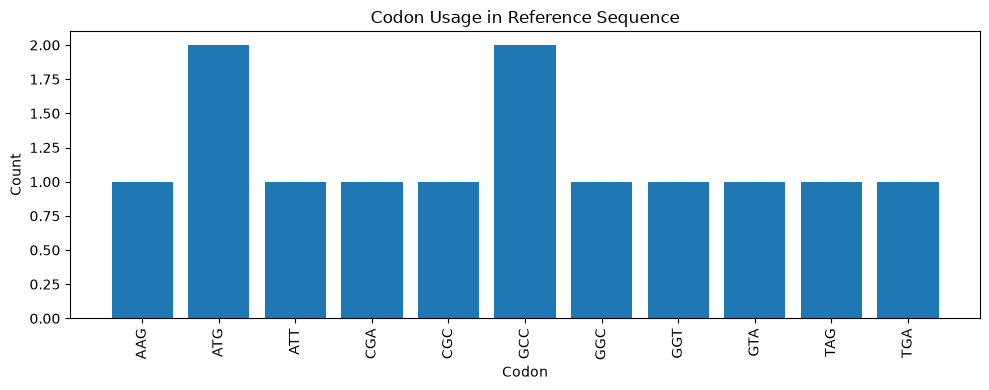

In [46]:
codon_counts = codon_usage(REFERENCE_SEQUENCE)

plt.figure(figsize=(10, 4))
plt.bar(list(codon_counts.keys()), list(codon_counts.values()))
plt.xticks(rotation=90)
plt.title("Codon Usage in Reference Sequence")
plt.xlabel("Codon")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

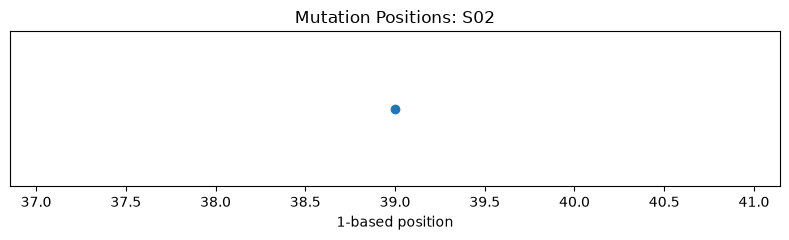

In [47]:
mutation_records = compare_equal_length_sequences(
    REFERENCE_SEQUENCE,
    SAMPLES[1]["sequence"]
)

mutation_positions = [record["position"] for record in mutation_records]

plt.figure(figsize=(8, 2.5))
plt.scatter(mutation_positions, [1] * len(mutation_positions))
plt.yticks([])
plt.xlabel("1-based position")
plt.title(f"Mutation Positions: {SAMPLES[1]['sample_id']}")
plt.tight_layout()
plt.show()

## 20. Integrated sample report

A reusable report function makes the workflow easier to inspect and demonstrate.

In [48]:
def print_sample_report(
    sample_id: str,
    sequence: str,
    reference: Optional[str] = None
) -> None:
    analysis = analyze_sequence(sequence)

    print("=" * 60)
    print(f"Sample: {sample_id}")
    print("=" * 60)
    print(f"Length:          {analysis['length']}")
    print(f"GC content:      {analysis['gc_percent']:.2f}%")
    print(f"AT content:      {analysis['at_percent']:.2f}%")
    print(f"N content:       {analysis['n_percent']:.2f}%")
    print(f"QC status:       {analysis['qc']['status']}")
    print(f"ATG count:       {analysis['atg_motif']['count']}")
    print(f"Simple ORFs:     {len(analysis['orfs'])}")

    if reference is not None:
        try:
            identity = positional_identity(reference, sequence)
            mutations = compare_equal_length_sequences(reference, sequence)
            print(f"Identity:        {identity:.2%}")
            print(f"SNV count:       {len(mutations)}")
        except ValueError as error:
            print(f"Comparison:      {error}")

    print("Nucleotide counts:", analysis["nucleotide_counts"])
    print()


for sample in SAMPLES:
    print_sample_report(
        sample["sample_id"],
        sample["sequence"],
        REFERENCE_SEQUENCE
    )

Sample: S01
Length:          39
GC content:      56.41%
AT content:      43.59%
N content:       0.00%
QC status:       pass
ATG count:       2
Simple ORFs:     2
Identity:        100.00%
SNV count:       0
Nucleotide counts: {'A': 9, 'T': 8, 'C': 8, 'G': 14}

Sample: S02
Length:          39
GC content:      56.41%
AT content:      43.59%
N content:       0.00%
QC status:       pass
ATG count:       2
Simple ORFs:     2
Identity:        97.44%
SNV count:       1
Nucleotide counts: {'A': 9, 'T': 8, 'C': 9, 'G': 13}

Sample: S03
Length:          39
GC content:      56.41%
AT content:      43.59%
N content:       0.00%
QC status:       pass
ATG count:       2
Simple ORFs:     2
Identity:        100.00%
SNV count:       0
Nucleotide counts: {'A': 9, 'T': 8, 'C': 8, 'G': 14}

Sample: S04
Length:          39
GC content:      58.97%
AT content:      41.03%
N content:       0.00%
QC status:       pass
ATG count:       3
Simple ORFs:     2
Identity:        94.87%
SNV count:       2
Nucleotide c

# 21. Complete end-to-end pipeline

The pipeline:

1. normalizes the sequence,
2. performs QC,
3. calculates composition,
4. searches for motifs,
5. generates the reverse complement,
6. translates three forward frames,
7. detects six-frame ORFs,
8. compares against a reference when lengths match.

In [49]:
def run_sequence_pipeline(
    sequence: str,
    reference: Optional[str] = None,
    min_length: int = 10
) -> Dict:
    seq = normalize_sequence(sequence)

    report = {
        "sequence": seq,
        "qc": quality_control(seq, min_length=min_length),
        "length": len(seq),
        "composition": nucleotide_counts(seq),
        "frequencies": nucleotide_frequencies(seq),
        "gc_percent": gc_content(seq),
        "at_percent": at_content(seq),
        "n_percent": ambiguous_percentage(seq),
        "atg_motif": find_motif(seq, "ATG"),
        "reverse_complement": reverse_complement(seq),
        "translations": {
            f"frame_{frame + 1}": translate_dna(seq, frame)
            for frame in range(3)
        },
        "orfs": find_six_frame_orfs(seq),
    }

    if reference is not None:
        ref = normalize_sequence(reference)

        if len(ref) == len(seq):
            report["comparison"] = {
                "identity": positional_identity(ref, seq),
                "mutations": compare_equal_length_sequences(ref, seq)
            }
        else:
            report["comparison"] = {
                "identity": None,
                "mutations": None,
                "note": (
                    "Lengths differ. Alignment is required before "
                    "position-aware comparison."
                )
            }

    return report


pipeline_result = run_sequence_pipeline(
    SAMPLES[1]["sequence"],
    reference=REFERENCE_SEQUENCE
)

print("QC:", pipeline_result["qc"])
print("GC%:", f"{pipeline_result['gc_percent']:.2f}")
print("Identity:", f"{pipeline_result['comparison']['identity']:.2%}")
print("Mutations:", pipeline_result["comparison"]["mutations"])

QC: {'valid': True, 'length': 39, 'invalid_bases': [], 'ambiguous_count': 0, 'ambiguous_fraction': 0.0, 'status': 'pass'}
GC%: 56.41
Identity: 97.44%
Mutations: [{'position': 39, 'reference': 'G', 'sample': 'C', 'type': 'SNV'}]


# 22. Dataset QC filtering

Before downstream analysis, it is often useful to separate sequences that pass QC from those that require review.

In [50]:
def split_by_qc(
    samples: List[Dict],
    min_length: int = 10
) -> Tuple[List[Dict], List[Dict]]:
    passed = []
    failed = []

    for sample in samples:
        qc = quality_control(sample["sequence"], min_length=min_length)

        if qc["valid"]:
            passed.append(sample)
        else:
            failed.append(sample)

    return passed, failed


passed_samples, failed_samples = split_by_qc(SAMPLES)

print("QC-passing samples:", [s["sample_id"] for s in passed_samples])
print("QC-review samples:", [s["sample_id"] for s in failed_samples])

QC-passing samples: ['S01', 'S02', 'S03', 'S04', 'S05']
QC-review samples: []


# 23. Biological interpretation: measurement versus conclusion

At this stage we can make descriptive computational statements such as:

- a sequence has a particular GC percentage,
- a motif occurs at specific positions,
- a sample differs from a reference at specific positions,
- a reading frame produces a particular translation,
- a sequence contains an ORF under our simplified rules.

We should **not** automatically conclude:

- that an ORF is a real gene,
- that a mutation is pathogenic,
- that a motif has a regulatory function,
- that a GC difference explains a phenotype,
- or that a sequence difference is clinically significant.

Those conclusions require additional evidence and domain-specific methods.

A core bioinformatics skill is knowing the difference between a **computational measurement** and a **biological interpretation**.

# 24. Common mistakes

### Mistake 1 — Treating raw strings as clean biological data
Normalize and validate first.

### Mistake 2 — Forgetting strand orientation
Many sequence analyses require consideration of the reverse complement.

### Mistake 3 — Calling positional comparison "alignment"
Position-by-position comparison assumes coordinate compatibility.

### Mistake 4 — Treating every ORF as a gene
An ORF is a sequence pattern, not proof of biological function.

### Mistake 5 — Ignoring ambiguous bases
`N` represents uncertainty and should be quantified.

### Mistake 6 — Building one giant function
Separate functions are easier to test, reuse, and maintain.

### Mistake 7 — Reporting numbers without context
A GC percentage or mutation count should be interpreted relative to the sequence, reference, dataset, and analysis assumptions.

# 25. Exercises

## Exercise 1 — Add RNA support

Create `normalize_rna_sequence()` and validate `A, U, C, G`.

Then implement RNA translation by converting `U → T` or by creating an RNA codon table.

## Exercise 2 — GC sliding window

Implement:

```python
gc_sliding_window(sequence, window_size)
```

and plot GC content across the sequence.

## Exercise 3 — Motif comparison

Compare `ATG` and `GGC` across all samples.

## Exercise 4 — Better ORF reporting

Add nucleotide length and protein length to the ORF report, then sort ORFs by length.

## Exercise 5 — Mutation classification

For equal-length sequences, classify substitutions as transitions or transversions:

- transitions: `A ↔ G`, `C ↔ T`
- transversions: all other substitutions

## Exercise 6 — Mutation impact

For a valid coding sequence, compare reference and sample translations and determine whether a nucleotide change changes the encoded amino acid.

# 26. Capstone project — Mini DNA Analysis Toolkit

Create:

```text
sequence_analysis.py
```

with reusable functions for:

```text
normalize_sequence()
quality_control()
nucleotide_counts()
nucleotide_frequencies()
gc_content()
at_content()
ambiguous_percentage()
find_motif()
reverse_complement()
get_codons()
translate_dna()
find_six_frame_orfs()
codon_usage()
compare_equal_length_sequences()
positional_identity()
analyze_sequence()
analyze_dataset()
```

Then create a separate notebook or script that imports your module and analyzes a collection of sequences.

### Minimum final report

Include:

1. sequence ID,
2. sequence length,
3. QC status,
4. GC percentage,
5. N percentage,
6. nucleotide composition,
7. motif counts,
8. number of ORFs,
9. reference/sample identity when applicable,
10. number and positions of SNVs.

### Portfolio extensions

Add FASTA input, CSV export, plots, command-line arguments, unit tests, logging, and eventually Biopython-based implementations.

# 27. What you have actually learned

This notebook covered:

### Data engineering
- normalization,
- validation,
- quality control,
- structured records.

### Sequence algorithms
- nucleotide counting,
- GC/AT calculation,
- motif searching,
- reverse complement,
- codon extraction,
- translation,
- ORF detection.

### Comparative analysis
- reference/sample comparison,
- equal-length SNV detection,
- positional identity.

### Numerical computing
- NumPy arrays,
- descriptive statistics.

### Visualization
- nucleotide composition,
- GC content,
- length distribution,
- motif positions,
- codon usage,
- mutation positions.

### Software engineering
- functions,
- type hints,
- dataclasses,
- reusable pipelines,
- separation of concerns.

> **You are no longer only learning Python. You are using Python to solve bioinformatics problems.**

# 28. Why Biopython comes next

We implemented many operations manually because that builds conceptual understanding.

The natural progression is:

```text
Python fundamentals
        ↓
Manual sequence algorithms
        ↓
Biopython
        ↓
Seq / MutableSeq
        ↓
SeqRecord
        ↓
SeqIO
        ↓
FASTA / FASTQ / GenBank
        ↓
Sequence alignment
        ↓
NCBI / Entrez
        ↓
BLAST
        ↓
Real bioinformatics datasets
```

The important skill is not memorizing library methods. It is understanding what problem a method solves, what assumptions it makes, what its output means, and how to validate that output.

# Final takeaway

A strong bioinformatics programmer should be able to move through three levels:

```text
Level 1 — Understand
What does this biological concept mean?

Level 2 — Implement
Can I reproduce the basic computation in Python?

Level 3 — Apply
Can I use the method correctly on biological data,
validate the result, visualize it, and explain its limitations?
```

This notebook is designed to move from Level 1 toward Level 3.

The next stage is to introduce **Biopython as a professional bioinformatics toolkit**, while preserving the concepts learned here.